In [1]:
from pathlib import Path
import IPython

def validate_results(
    metrics_dir: str = "metrics/",
    *,
    clk_mhz: float | None = None,
    exclude_pct: float = 0.0,
    show: bool = True,
    # BACKWARD-COMPAT: old single-file arg maps to core cycles
    cycles_file: str | None = "cycles_core.npy",
    # NEW: explicit dual files
    cycles_core_file: str | None = None,
    cycles_e2e_file: str | None = None,
    # Optional power traces (as saved by on_target.py)
    power_abs: str | None = "power_abs.npy",
    power_dyn: str | None = "power_dyn.npy",
) -> None:
    """
    Launch validate_results.py inside the current IPython kernel with
    the right flags for cycles(power) files.
    """
    mdir = Path(metrics_dir).expanduser().resolve()
    if not mdir.exists():
        raise FileNotFoundError(f"{mdir} does not exist")

    # Prefer explicit new params; fall back to legacy cycles_file for core.
    core_path = cycles_core_file if cycles_core_file is not None else cycles_file
    e2e_path  = cycles_e2e_file

    cli_parts = [
        "validate_results.py",
        "-m", str(mdir),
    ]

    # Map to the new, unambiguous flags
    if core_path:
        cli_parts += ["--cycles-core", core_path]
    if e2e_path:
        cli_parts += ["--cycles-e2e", e2e_path]

    # Power traces (only pass if not None)
    if power_abs:
        cli_parts += ["--power-abs", power_abs]
    if power_dyn:
        cli_parts += ["--power-dyn", power_dyn]

    if clk_mhz is not None:
        cli_parts += ["--clk-mhz", str(clk_mhz)]
    if exclude_pct > 0.0:
        cli_parts += ["--exclude-pct", str(exclude_pct)]
    if not show:
        cli_parts.append("--no-show")

    ip = IPython.get_ipython()
    if ip is None:
        raise RuntimeError("No active IPython kernel; run this from a notebook or IPython.")
    ip.run_line_magic("run", " ".join(cli_parts))


In [2]:
import tensorflow as tf, tf2onnx

model = tf.keras.models.load_model("models/keras/cnn_model.h5", compile=False)
model.summary()

sig = [tf.TensorSpec([None, 28, 28, 1], tf.float32, name="images")]  # adapt!

onnx_model, _ = tf2onnx.convert.from_keras(model,
                                           input_signature=sig,
                                           opset=18,
                                           output_path="models/onnx/cnn_model.onnx")


Model: "keras_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_3 (InputLayer)            │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_0 (Conv2D)                 │ (None, 26, 26, 16)     │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_0 (BatchNormalization)  │ (None, 26, 26, 16)     │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_0 (Activation)         │ (None, 26, 26, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_0 (MaxPooling2D)           │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 11, 11, 24)     │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (BatchNormalization)  │ (None, 11, 11, 24)     │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (Activation)         │ (None, 11, 11, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 5, 5, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 600)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_0 (Dense)                 │ (None, 42)             │        25,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_0 (BatchNormalization) │ (None, 42)             │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_act_0 (Activation)        │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (Dense)            │ (None, 10)             │           430 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,558 (115.46 KB)

 Trainable params: 29,394 (114.82 KB)

 Non-trainable params: 164 (656.00 B)

In [3]:
import onnx
from onnx2pytorch import ConvertModel

# Convert ONNX model to PyTorch
pytorch_model = ConvertModel(
        onnx_model,
        experimental=True       # removes the batch-size==1 guard
)
# Save the PyTorch model
import torch
torch.save(pytorch_model.state_dict(), "models/pytorch/cnn_model.pth")
pytorch_model

c:\Users\SagittariusA\Documents\Projects\AI_ON_FPGA_TARGET_SCRIPTS\.venv\Lib\site-packages\onnx2pytorch\convert\layer.py:30: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  layer.weight.data = torch.from_numpy(numpy_helper.to_array(weight))
c:\Users\SagittariusA\Documents\Projects\AI_ON_FPGA_TARGET_SCRIPTS\.venv\Lib\site-packages\onnx2pytorch\convert\model.py:147: UserWarning: Using experimental implementation that allows 'batch_size > 1'.Batchnorm layers could potentially produce false outputs.
  warnings.warn(


ConvertModel(
  (Reshape_keras_baseline_1/bn_conv_0_1/batchnorm/mul_1__6:0): Reshape(shape=[-1  1 28 28])
  (Conv_Conv__34:0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (Relu_keras_baseline_1/conv_act_0_1/Relu:0): ReLU(inplace=True)
  (MaxPool_keras_baseline_1/pool_0_1/MaxPool2d:0): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (Conv_Conv__36:0): Conv2d(16, 24, kernel_size=(3, 3), stride=(1, 1))
  (Relu_keras_baseline_1/conv_act_1_1/Relu:0): ReLU(inplace=True)
  (MaxPool_keras_baseline_1/pool_1_1/MaxPool2d:0): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (Transpose_Transpose__40:0): Transpose()
  (Shape_Shape__42:0): Shape()
  (Gather_keras_baseline_1/flatten_2_1/Shape:0): Gather()
  (Cast_keras_baseline_1/flatten_2_1/Shape__22:0): Cast(dtype=torch.int32)
  (Slice_keras_baseline_1/flatten_2_1/strided_slice:0): Slice()
  (Cast_keras_baseline_1/flatten_2_1/Reshape__33:0): Cast(dtype=torch.int64)
 

In [4]:
import torchvision 

from torchvision import transforms

# Define the transformation to convert MNIST images to tensor
transform = transforms.Compose([
    transforms.ToTensor()
])

#load the MNIST dataset
mnist_dataset = torchvision.datasets.MNIST(root='data', train=False, download=True, transform=transform)

# Create a DataLoader for the dataset
mnist_loader = torch.utils.data.DataLoader(mnist_dataset, batch_size=100, shuffle=False)



In [5]:
from comp_utils.helper_functions import evaluate_model

import torch
from comp_utils.helper_functions import evaluate_model
from comp_utils.metrics_plot import (
    plot_eval_summary,
    plot_compare_latency,
    plot_compare_throughput,
)
import matplotlib.pyplot as plt

# Run evaluations
m1   = evaluate_model(pytorch_model, mnist_loader, device="dml", exclude_pct=1.0, warmup_batches=10, progress=True)


c:\Users\SagittariusA\Documents\Projects\AI_ON_FPGA_TARGET_SCRIPTS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Eval: 100%|██████████| 100/100 [00:00<00:00, 122.90it/s]

Backend            : dml
Accuracy           : 98.1600%  (9816/10000)
Latency / sample   : 0.0317 ms ± 0.0029 (min=0.0274, max=0.0388, P50=0.0317, P90=0.0355, P99=0.0381) [batches=99]
Throughput (batch) : 31686.10 ips ± 2863.25 (P50=31492.10, P90=35745.23, P99=36251.07)
Throughput (global): 31466.70 ips (total_time=0.318s, samples=10000)


In [6]:
m_cpu  = evaluate_model(pytorch_model, mnist_loader, device="cpu", exclude_pct=1.0, progress=True)

Eval: 100%|██████████| 100/100 [00:00<00:00, 155.38it/s]

Backend            : cpu
Accuracy           : 98.1600%  (9816/10000)
Latency / sample   : 0.0181 ms ± 0.0015 (min=0.0152, max=0.0218, P50=0.0179, P90=0.0202, P99=0.0214) [batches=99]
Throughput (batch) : 55414.13 ips ± 4585.62 (P50=55806.69, P90=61689.56, P99=65439.15)
Throughput (global): 55115.22 ips (total_time=0.181s, samples=10000)


In [7]:
m_dml  = evaluate_model(pytorch_model, mnist_loader, device="dml", exclude_pct=1.0, progress=True)

Eval: 100%|██████████| 100/100 [00:00<00:00, 123.40it/s]

Backend            : dml
Accuracy           : 98.1600%  (9816/10000)
Latency / sample   : 0.0313 ms ± 0.0027 (min=0.0269, max=0.0378, P50=0.0313, P90=0.0347, P99=0.0368) [batches=99]
Throughput (batch) : 32112.45 ips ± 2896.16 (P50=31898.94, P90=36281.60, P99=36789.11)
Throughput (global): 31894.60 ips (total_time=0.314s, samples=10000)


[GPU1] GPU 1 BRD PWR  n=51  duration=12.505s
  idle ≈ 35.00 W  (bottom 10%)
  mean  42.51 W  ± 9.66
  min/max 35.00/65.00 W
  P50/P90/P99  38.00/64.00/65.00 W
  dyn mean above idle ≈ 7.51 W
[GPU1 util] GPU 1 UTIL  n=51  duration=12.505s
  idle ≈ 4.33 W  (bottom 10%)
  mean  8.45 W  ± 4.64
  min/max 4.00/22.00 W
  P50/P90/P99  7.00/13.00/22.00 W
  dyn mean above idle ≈ 4.14 W


c:\Users\SagittariusA\Documents\Projects\AI_ON_FPGA_TARGET_SCRIPTS\comp_utils\power_plots.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ts = pd.to_datetime(df["TIME STAMP"], errors="coerce")


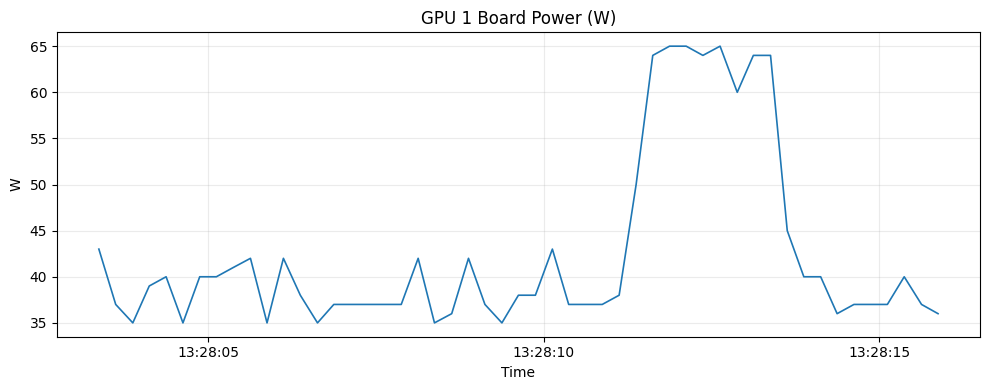

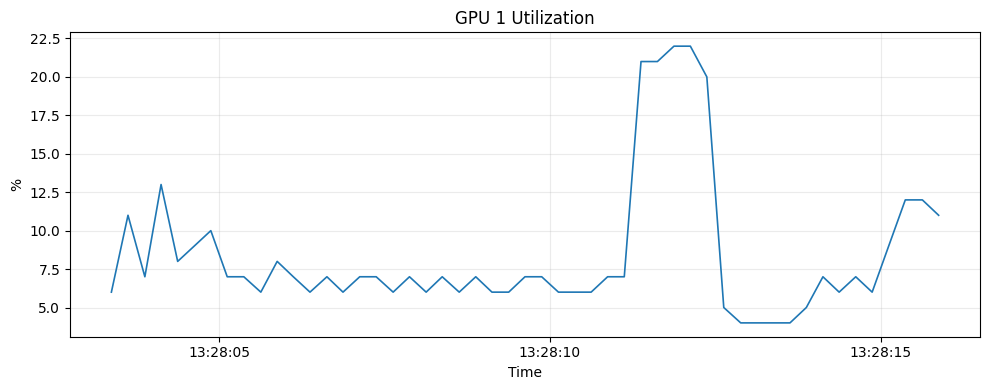

In [4]:
from comp_utils.power_plots import *

df = load_hw_csv_simple("Hardware.20250817-132816.CSV")



# GPU board power (Watts)
st_gpu = compute_idle_and_metrics(df, "GPU 1 BRD PWR", idle_seconds=5.0, idle_percentile=10.0, exclude_top_pct=1.0)
print_power_summary(st_gpu, label="GPU1")

# GPU util, CPU util work too (they're % units, but same API)
st_gpu_util = compute_idle_and_metrics(df, "GPU 1 UTIL", idle_seconds=5.0, idle_percentile=10.0)

print_power_summary(st_gpu_util, label="GPU1 util")


plot_series(df, "GPU 1 BRD PWR", title="GPU 1 Board Power (W)", ylabel="W")
plot_series(df, "GPU 1 UTIL",    title="GPU 1 Utilization",     ylabel="%")


In [9]:
validate_results(metrics_dir="metrics/optim", clk_mhz=200, exclude_pct=0.0)  # Validate results and generate figures

HW vs GT Accuracy    : 98.020000%
HW vs Golden Accuracy: 99.960000%

[COMMS]
  Latency   : 0.4985 ms ± 0.3001  (min=0.4190, max=9.0040)
            : P50=0.4590  P90=0.5380  P99=0.9391
  Throughput: 2101.14 inf/s ± 247.33

[INF]
  Latency   : 0.1948 ms ± 0.1512  (min=0.1610, max=8.3400)
            : P50=0.1800  P90=0.2171  P99=0.3290
  Throughput: 5362.03 inf/s ± 628.61

[CYCLES core]   (10000 samples)
  Mean cycles : 2642 ± 1  (min=2642, max=2685)
            : P50=2642  P90=2642  P99=2642
  Mean time  : 13.210 µs (75698.09 inf/s @ 200 MHz)

[CYCLES e2e]   (10000 samples)
  Mean cycles : 13016 ± 38778  (min=10574, max=1655538)
            : P50=11214  P90=12011  P99=21409
  Mean time  : 65.079 µs (15365.89 inf/s @ 200 MHz)

[CYCLES overhead (e2e - core)]   (10000 samples)
  Mean cycles : 10374 ± 38778  (min=7932, max=1652896)
            : P50=8571  P90=9369  P99=18767
  Mean time  : 51.869 µs (19279.40 inf/s @ 200 MHz)

[POWER absolute]   (154 samples)
  Mean  : 4109.94 mW ± 322.65


In [10]:
validate_results(metrics_dir="metrics/optim64", clk_mhz=200, exclude_pct=0.0)  # Validate results and generate figures

HW vs GT Accuracy    : 98.020000%
HW vs Golden Accuracy: 99.960000%

[COMMS]
  Latency   : 0.4889 ms ± 0.2967  (min=0.4180, max=8.8310)
            : P50=0.4490  P90=0.5210  P99=0.9910
  Throughput: 2148.49 inf/s ± 250.65

[INF]
  Latency   : 0.1914 ms ± 0.1713  (min=0.1600, max=8.4050)
            : P50=0.1740  P90=0.2100  P99=0.3390
  Throughput: 5498.54 inf/s ± 635.21

[CYCLES core]   (10000 samples)
  Mean cycles : 2642 ± 1  (min=2642, max=2684)
            : P50=2642  P90=2642  P99=2642
  Mean time  : 13.210 µs (75698.42 inf/s @ 200 MHz)

[CYCLES e2e]   (10000 samples)
  Mean cycles : 12531 ± 31260  (min=10700, max=1656168)
            : P50=11242  P90=11883  P99=20750
  Mean time  : 62.656 µs (15960.11 inf/s @ 200 MHz)

[CYCLES overhead (e2e - core)]   (10000 samples)
  Mean cycles : 9889 ± 31260  (min=8058, max=1653526)
            : P50=8600  P90=9241  P99=18108
  Mean time  : 49.446 µs (20224.12 inf/s @ 200 MHz)

[POWER absolute]   (152 samples)
  Mean  : 4035.39 mW ± 338.37
 